Привет, меня зовут Артем. Сегодня я проверю твой проект.
<br> Дальнейшее общение будет происходить на "ты" если это не вызывает никаких проблем.
<br> Желательно реагировать на каждый мой комментарий ('исправил', 'не понятно как исправить ошибку', ...)
<br> Пожалуйста, не удаляй комментарии ревьюера, так как они повышают качество повторного ревью.

Комментарии будут в <font color='green'>зеленой</font>, <font color='blue'>синей</font> или <font color='red'>красной</font> рамках:

<div class="alert alert-block alert-success">
<b>Успех:</b> Если все сделано отлично
</div>

<div class="alert alert-block alert-info">
<b>Совет: </b> Если можно немного улучшить
</div>

<div class="alert alert-block alert-danger">
<b>Ошибка:</b> Если требуются исправления. Работа не может быть принята с красными комментариями.
</div>

-------------------

Будет очень хорошо, если ты будешь помечать свои действия следующим образом:
<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> ...
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> Были внесены следующие изменения ...
</div>

### <font color='orange'>Общее впечатление</font>
* Большое спасибо за проделанную работу. Видно, что приложено много усилий.
* Выводы и рассуждения получились содержательными, их было интересно читать.
* Радует, что тебе удалось разобраться с техникой бутстрапа.
* Отлично, что доверительный интервал и риск убытков посчитаны верно.
* Редко, кто сдает эту работу с первого раза, молодец!
* Проект может быть зачтен, но я его отправлю назад, чтобы у тебя была возможность задать вопросы и внести правки, при желании. Однако, ты можешь просто вернуть проект в таком же виде и я его зачту.

<div class="alert alert-block alert-warning">
<b>Комментарий студента:</b> 
    
Артем, привет! Спасибо за комментарии 🙌

По написанию переменных-констант как раз были сомнения, запомню 🤝🏼
    
</div>

### <font color='orange'>Общее впечатление (ревью 2)</font>
* Проект зачтен!
* Удачи в дальнейшем обучении и следующих работах!

# Описание проекта

Добывающая компания «ГлавРосГосНефть» принимает решение о локации новой скважины.

Компания предоставила данные о пробах нефти в трёх регионах: в каждом 10 000 месторождений, где измерили качество нефти и объём её запасов. 

Необходимо построить модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль.

**Для проведения исследования доступны следующие данные:** 
- данные геологоразведки в первом регионе;
- данные геологоразведки во втором регионе;
- данные геологоразведки в третьем регионе.

**Шаги для выбора локации:**

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

**План проведения исследования:**
- изучим данные;
- проведём предобработку;
- выполним исследовательский и корреляционный анализ данных;
- обучим и проверим модель МО для каждого региона;
- рассчитаем прибыль по выбранным скважинам и предсказаниям модели;
- рассчитаем риски и прибыль для каждого региона;
- сформулируем выводы и предложения.

---
## Загрузка и чтение данных

### Подготовка к чтению данных

<font size="3"> Импортируем необходимые библиотеки:

In [1]:
pip install missingno -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install phik -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import pandas as pd
import phik
import scipy.stats as st
import seaborn as sns

from phik.report import plot_correlation_matrix
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

<div class="alert alert-block alert-success">
<b>Успех:</b> Отлично, что все импорты собраны в первой ячейке ноутбука! Если у того, кто будет запускать твой ноутбук будут отсутствовать некоторые библиотеки, то он это увидит сразу, а не в процессе!
</div>

<font size="3">
Зададим настройки:

In [4]:
sns.set_theme(style="darkgrid", palette="icefire")
pd.set_option('display.max_columns', None)
pd.options.display.float_format ='{:,.3f}'.format

RANDOM_STATE = 42
state = np.random.RandomState(12345)

### Чтение данных

<font size="3">

- **Датасет `geo_data_0`**

<font size="3"> Считаем данные геологоразведки первого региона и сохраним в переменную `location_one`:

In [5]:
location_one = pd.read_csv('/datasets/geo_data_0.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `location_one` на экран:

In [6]:
location_one.head(20)

,id,f0,f1,f2,product
0,txEyH,0.706,-0.498,1.221,105.280
1,2acmU,1.335,-0.340,4.365,73.038
2,409Wp,1.023,0.152,1.420,85.266
3,iJLyR,-0.032,0.139,2.979,168.621
4,Xdl7t,1.988,0.155,4.752,154.037
5,wX4Hy,0.970,0.490,-0.735,64.742
6,tL6pL,0.645,0.531,1.780,49.055
7,BYPU6,-0.401,0.808,-5.625,72.943
8,j9Oui,0.643,-0.552,2.372,113.356
9,OLuZU,2.173,0.564,9.442,127.911


<font size="3">

- **Датасет `geo_data_1`**

<font size="3"> Считаем данные геологоразведки второго региона и сохраним в переменную `location_two`:

In [7]:
location_two = pd.read_csv('/datasets/geo_data_1.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `location_two` на экран:

In [8]:
location_two.head(20)

,id,f0,f1,f2,product
0,kBEdx,-15.001,-8.276,-0.006,3.179
1,62mP7,14.272,-3.475,0.999,26.953
2,vyE1P,6.263,-5.948,5.001,134.766
3,KcrkZ,-13.081,-11.506,4.999,137.945
4,AHL4O,12.702,-8.147,5.004,134.766
5,HHckp,-3.328,-2.205,3.004,84.039
6,h5Ujo,-11.143,-10.133,4.002,110.992
7,muH9x,4.235,-0.001,2.005,53.907
8,YiRkx,13.355,-0.332,4.999,134.766
9,jG6Gi,1.069,-11.026,4.998,137.945


<font size="3">

- **Датасет `geo_data_2`**

<font size="3"> Считаем данные геологоразведки третьего региона и сохраним в переменную `location_three`:

In [9]:
location_three = pd.read_csv('/datasets/geo_data_2.csv')

<font size="3"> Выведем первые 20 строчек датафрейма `location_three` на экран:

In [10]:
location_three.head(20)

,id,f0,f1,f2,product
0,fwXo0,-1.147,0.963,-0.829,27.759
1,WJtFt,0.263,0.270,-2.530,56.070
2,ovLUW,0.195,0.289,-5.586,62.872
3,q6cA6,2.236,-0.554,0.930,114.573
4,WPMUX,-0.516,1.716,5.899,149.601
5,LzZXx,-0.758,0.711,2.586,90.222
6,WBHRv,-0.575,0.318,1.774,45.641
7,XO8fn,-1.907,-2.458,-0.177,72.481
8,ybmQ5,1.776,-0.279,3.004,106.617
9,OilcN,-1.214,-0.439,5.923,52.955


### Изучение датафреймов

<font size="3">
    
Изучим структуру и полноту полученных датафреймов

- **Датафрейм `location_one`**

In [11]:
location_one.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


<AxesSubplot:>

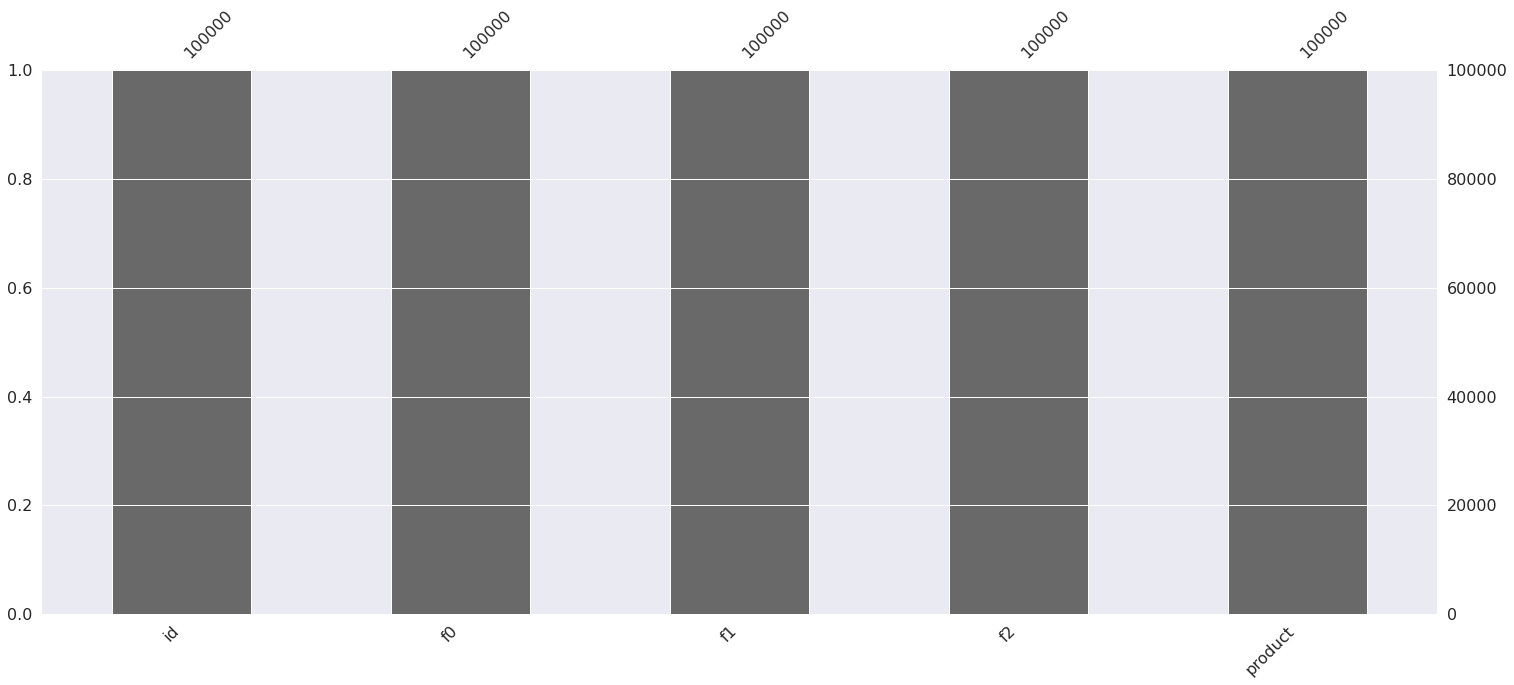

In [12]:
msno.bar(location_one)

<font size="3">

- **Датафрейм `location_two`**

In [13]:
location_two.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


<AxesSubplot:>

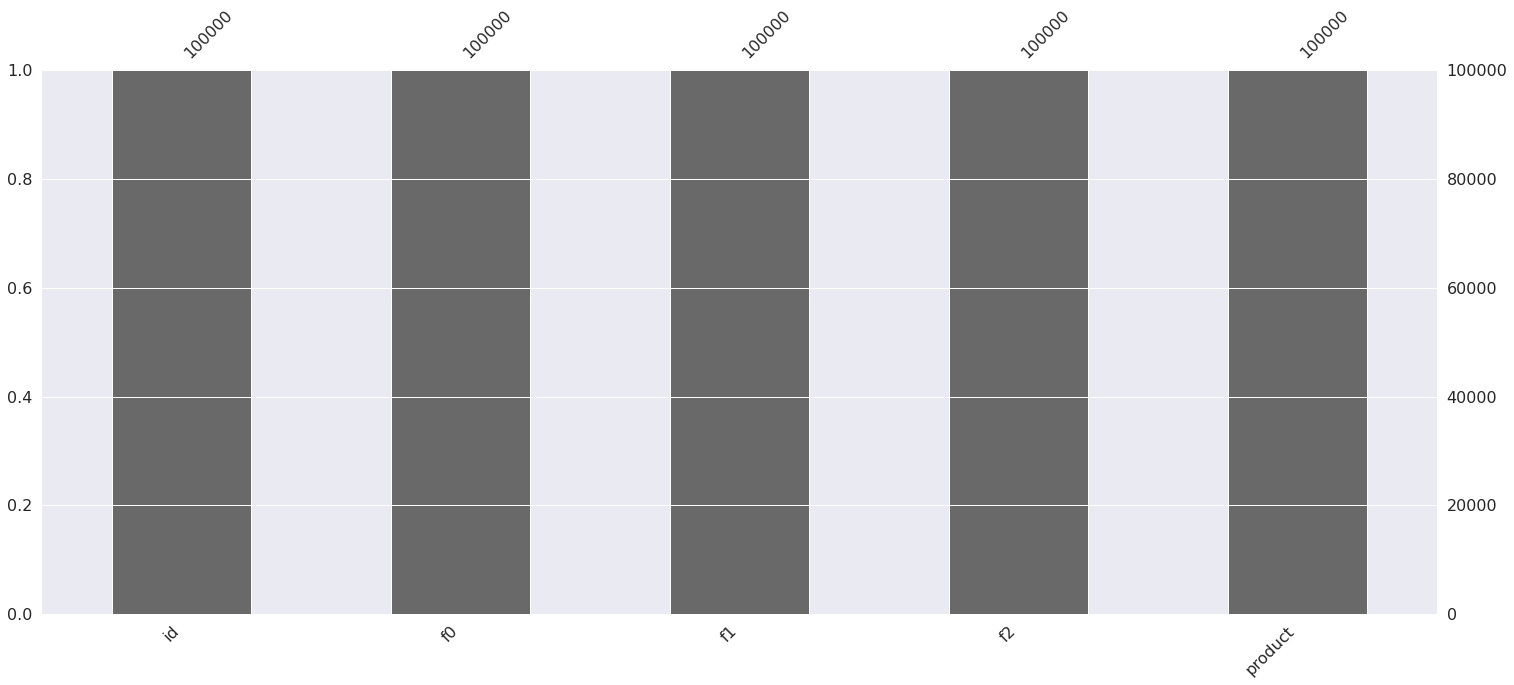

In [14]:
msno.bar(location_two)

<font size="3">

- **Датафрейм `location_three`**

In [15]:
location_three.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


<AxesSubplot:>

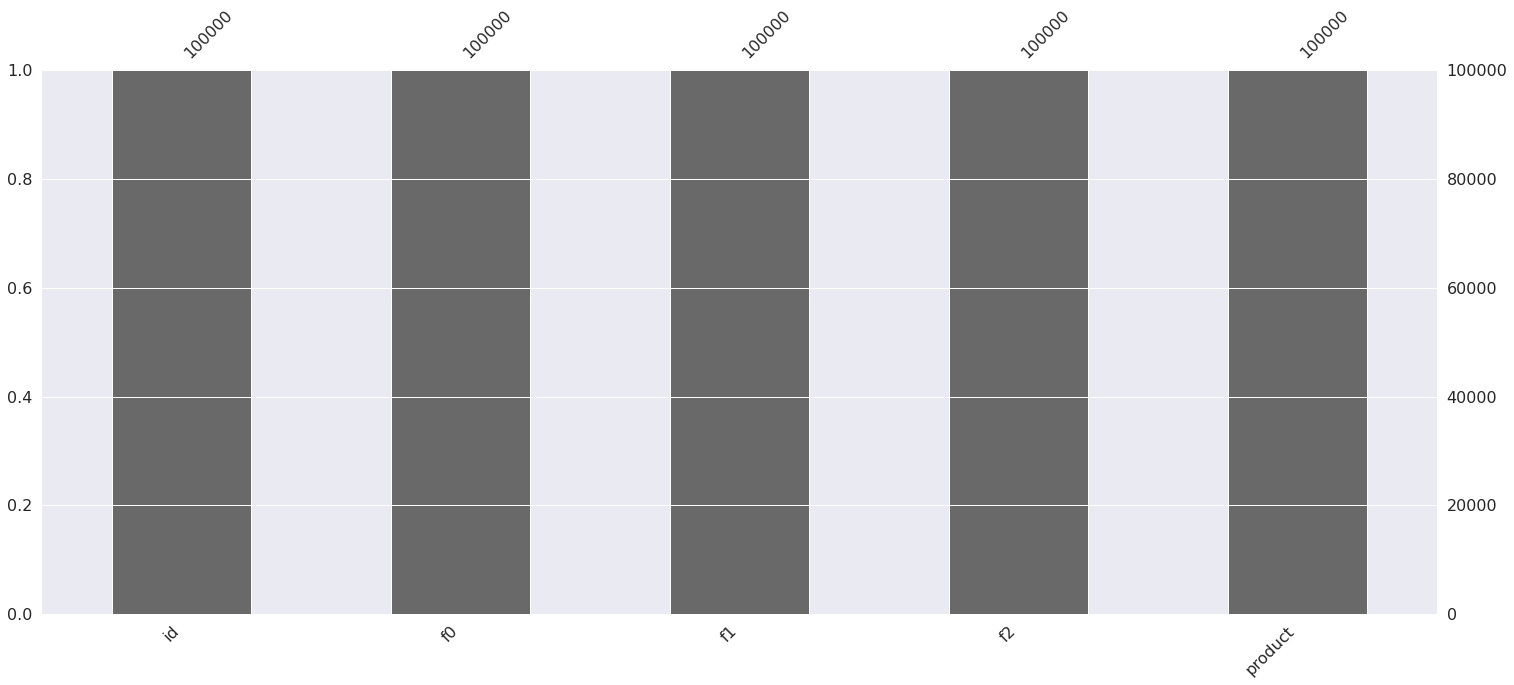

In [16]:
msno.bar(location_three)

<font size="3">
    
**Вывод:**

Полученные датафреймы содержат следующие данные:

  * `id` — уникальный идентификатор скважины;
  * `f0`, `f1`, `f2` — три признака точек;
  * `product` — объём запасов в скважине (тыс. баррелей)

Предварительно можно утверждать, что данных достаточно для проведения исследования. 
    
В датасетах отсутствуют пропущенные значения, столбцы датафреймов именованы корректно.
    
Стоит подробнее изучить тип имеющихся данных, а также в данных могут присутствовать дубликаты.

---

## Предобработка данных

### Тип данных


<font size="3"> Убедимся, что в датафреймах корретный тип данных.
    
- **датафрейм `location_one`:**

In [17]:
location_one.dtypes

id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object

- **датафрейм `location_two`:**

In [18]:
location_two.dtypes

id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object

- **датафрейм `location_three`:**

In [19]:
location_three.dtypes

id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object

<font size="3">

**Вывод**

Все столбцы в датафреймах содержат корректный тип данных: количественные столбцы имеют тип `float64`, категориальные - тип `object`.

### Проверка пропусков

<font size="3"> Гистограммы `msno` показали отсутствие пропущенных значений в датафреймах, дополнительная обработка не требуется.

### Проверка явных дубликатов

<font size="3">
    
Проверим наличие явных дубликатов в датафреймах.

- **датафрейм `location_one`:**

In [20]:
location_one.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

<font size="3">
 
- **датафрейм `location_two`:**

In [21]:
location_two.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

<font size="3">
 
- **датафрейм `location_three`:**

In [22]:
location_three.duplicated().sum()

0

<font size="3"> Явные дубликаты отсутствуют.

### Проверка неявных дубликатов

<font size="3"> Проверим значения столбца `id` в датафреймах на уникальность.

- **датафрейм `location_one`:**

In [23]:
(location_one['id']
   .value_counts()
   .reset_index()
   .query('id > 1')
   .rename(columns={'index':'id', 'id':'count'}))

,id,count
0,fiKDv,2
1,Tdehs,2
2,bsk9y,2
3,A5aEY,2
4,AGS9W,2
5,74z30,2
6,bxg6G,2
7,TtcGQ,2
8,HZww2,2
9,QcMuo,2


<font size="3"> Значения уникального идентификатора скважины не уникальны, данный столбец можно удалить.

In [24]:
location_one.drop('id', axis=1, inplace=True)

<font size="3"> Проверим результат:

In [25]:
location_one.head()

,f0,f1,f2,product
0,0.706,-0.498,1.221,105.280
1,1.335,-0.340,4.365,73.038
2,1.023,0.152,1.420,85.266
3,-0.032,0.139,2.979,168.621
4,1.988,0.155,4.752,154.037


<font size="3">
 
- **датафрейм `location_two`:**

In [26]:
(location_two['id']
   .value_counts()
   .reset_index()
   .query('id > 1')
   .rename(columns={'index':'id', 'id':'count'}))

,id,count
0,wt4Uk,2
1,bfPNe,2
2,LHZR0,2
3,5ltQ6,2


<font size="3"> Значения в столбце `id` также не уникальны, столбец можно удалить.

In [27]:
location_two.drop('id', axis=1, inplace=True)

<font size="3"> Проверим результат:

In [28]:
location_two.head()

,f0,f1,f2,product
0,-15.001,-8.276,-0.006,3.179
1,14.272,-3.475,0.999,26.953
2,6.263,-5.948,5.001,134.766
3,-13.081,-11.506,4.999,137.945
4,12.702,-8.147,5.004,134.766


<font size="3">
 
- **датафрейм `location_three`:**

In [29]:
(location_three['id']
   .value_counts()
   .reset_index()
   .query('id > 1')
   .rename(columns={'index':'id', 'id':'count'}))

,id,count
0,xCHr8,2
1,KUPhW,2
2,VF7Jo,2
3,Vcm5J,2


<font size="3"> Значения не уникальны, удалим столбец.

In [30]:
location_three.drop('id', axis=1, inplace=True)

<font size="3"> Проверим результат:

In [31]:
location_three.head()

,f0,f1,f2,product
0,-1.147,0.963,-0.829,27.759
1,0.263,0.270,-2.530,56.070
2,0.195,0.289,-5.586,62.872
3,2.236,-0.554,0.930,114.573
4,-0.516,1.716,5.899,149.601


<font size="3">

**Вывод**

Для корректного проведения исследования выполнена предобработка данных:

- Проверены типы данных;
- Изучены пропуски в датафреймах;
- Проверены дубликаты в датафреймах, в том числе и неявные.

---
## Исследовательский анализ данных

<font size="3"> Проведём исследовательский анализ количественных признаков датафреймов.

<font size="3"> Напишем функцию `visuals`, которая построит гистограмму распределения, коробчатую диаграмму и выведет метод `describe()`:

In [32]:
def visuals(df, cat):
    display(df[cat].describe())
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,6))
    
    df[cat].plot(kind='hist', bins=20, ax=axes[0])
    axes[0].set_title('Гистограмма распределения', fontsize=14)
    axes[0].set_ylabel('Частота встречаемости')
    axes[0].set_xlabel('Наблюдаемые значения')
    
    df[cat].plot(kind='box', ax=axes[1], rot=0)
    axes[1].set_title('Разброс значений признаков', fontsize=14)
    axes[1].set_xlabel('Категория')
    axes[1].set_ylabel('Наблюдаемые значения')
    plt.show()

<font size="3">
    
**Датафейм `location_one`:**
    
- **Признак "f0"**

count   100,000.000
mean          0.500
std           0.872
min          -1.409
25%          -0.073
50%           0.502
75%           1.074
max           2.362
Name: f0, dtype: float64

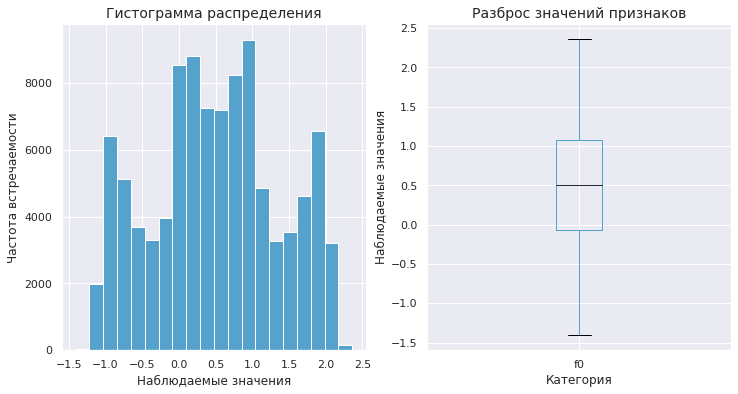

In [33]:
visuals(location_one, 'f0')

<font size="3">
    
**Вывод:**
        
Большинство значений признака располагается в промежутке от -0.073 до 1.074 со средним значением в 0.5.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "f1"**

count   100,000.000
mean          0.250
std           0.504
min          -0.848
25%          -0.201
50%           0.250
75%           0.701
max           1.344
Name: f1, dtype: float64

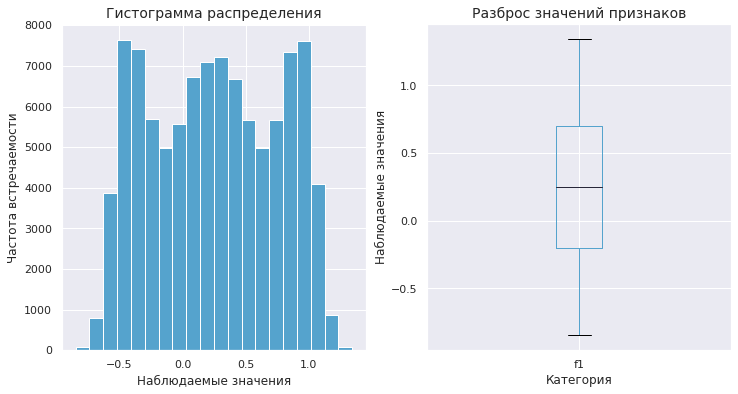

In [34]:
visuals(location_one, 'f1')

<font size="3">
    
**Вывод:**
        
Большинство значений признака располагается в промежутке от -0.201 до 0.701 со средним значением в 0.25.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "f2"**

count   100,000.000
mean          2.503
std           3.248
min         -12.088
25%           0.288
50%           2.516
75%           4.715
max          16.004
Name: f2, dtype: float64

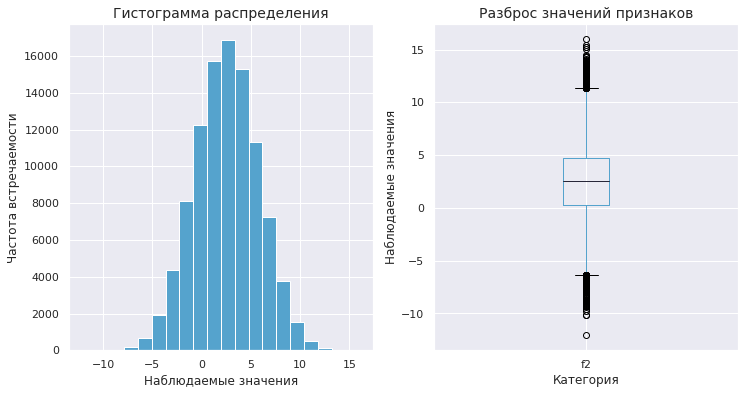

In [35]:
visuals(location_one, 'f2')

<font size="3">
    
**Вывод:**
        
Признак распределён нормально, большинство значений располагается в промежутке от 0.288 до 4.715 со средним значением в 2.503.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "product"**

count   100,000.000
mean         92.500
std          44.289
min           0.000
25%          56.498
50%          91.850
75%         128.564
max         185.364
Name: product, dtype: float64

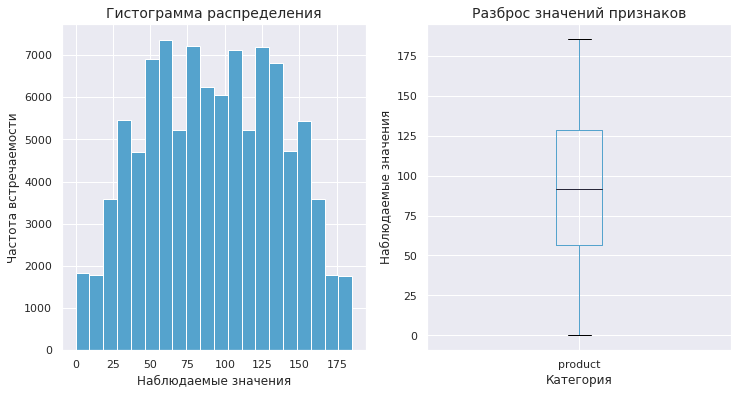

In [36]:
visuals(location_one, 'product')

<font size="3">
    
**Вывод:**
        
Большинство значений признака располагается в промежутке от 56.498 до 128.564 со средним значением в 92.500 тысяч баррелей.

Выбросы и аномалии в данных отсутствуют.

---

<font size="3">
    
**Датафейм `location_two`:**
    
- **Признак "f0"**

count   100,000.000
mean          1.141
std           8.966
min         -31.610
25%          -6.299
50%           1.153
75%           8.621
max          29.422
Name: f0, dtype: float64

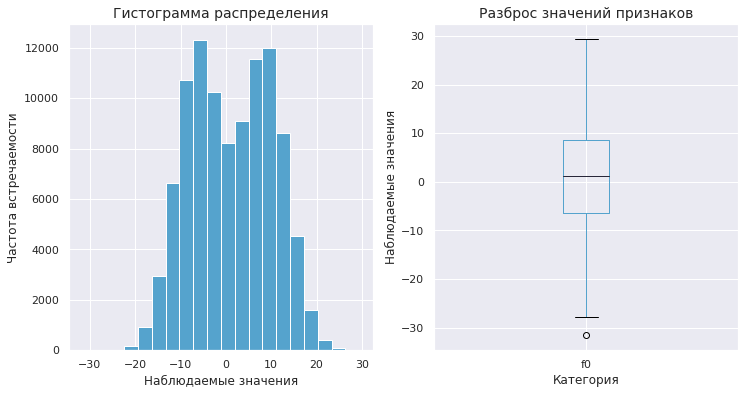

In [37]:
visuals(location_two, 'f0')

<font size="3">
    
**Вывод:**
        
Большинство значений признака располагается в промежутке от -6.299 до 8.621 со средним значением в 1.141.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "f1"**

count   100,000.000
mean         -4.797
std           5.120
min         -26.359
25%          -8.268
50%          -4.813
75%          -1.333
max          18.734
Name: f1, dtype: float64

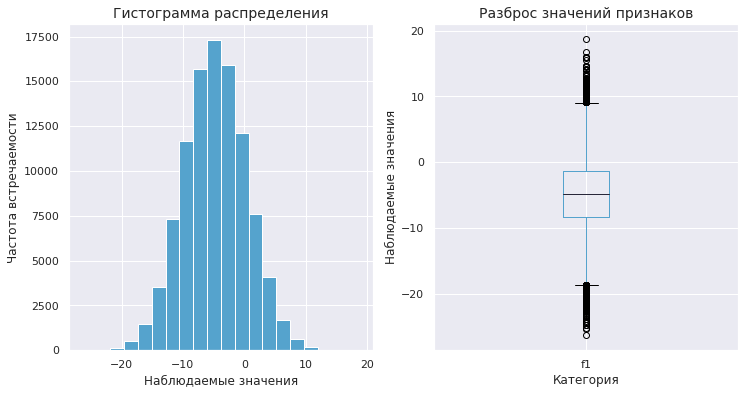

In [38]:
visuals(location_two, 'f1')

<font size="3">
    
**Вывод:**
        
Признак распределён нормально, большинство значений располагается в промежутке от -8.268 до -1.333 со средним значением в -4.797.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "f2"**

count   100,000.000
mean          2.495
std           1.704
min          -0.018
25%           1.000
50%           2.011
75%           4.000
max           5.020
Name: f2, dtype: float64

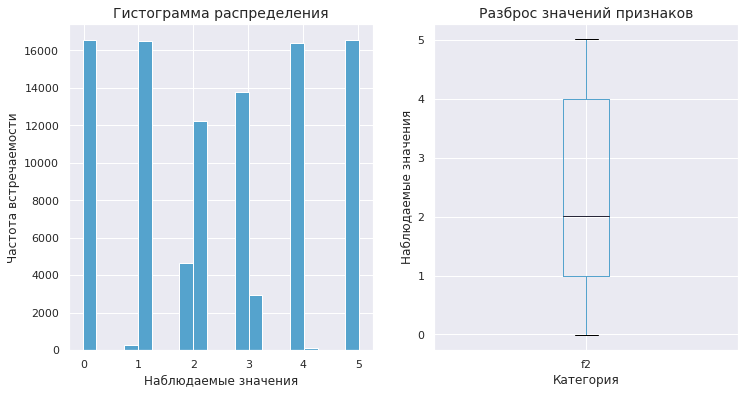

In [39]:
visuals(location_two, 'f2')

<font size="3">
    
**Вывод:**
        
Большинство значений признака располагается в промежутке от 1.000 до 4.000 со средним значением в 2.495.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "product"**

count   100,000.000
mean         68.825
std          45.944
min           0.000
25%          26.953
50%          57.086
75%         107.813
max         137.945
Name: product, dtype: float64

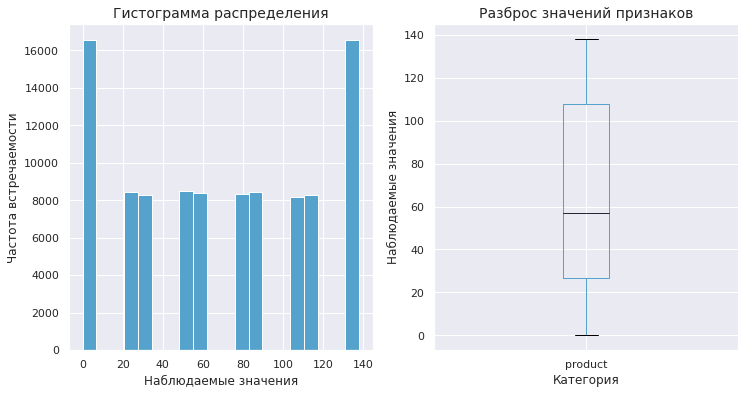

In [40]:
visuals(location_two, 'product')

<font size="3">
    
**Вывод:**
        
Большинство значений признака располагается в промежутке от 26.953 до 107.813 со средним значением в 68.825 тысяч баррелей.

Выбросы и аномалии в данных отсутствуют.

---

<font size="3">
    
**Датафейм `location_three`:**
    
- **Признак "f0"**

count   100,000.000
mean          0.002
std           1.732
min          -8.760
25%          -1.162
50%           0.009
75%           1.159
max           7.238
Name: f0, dtype: float64

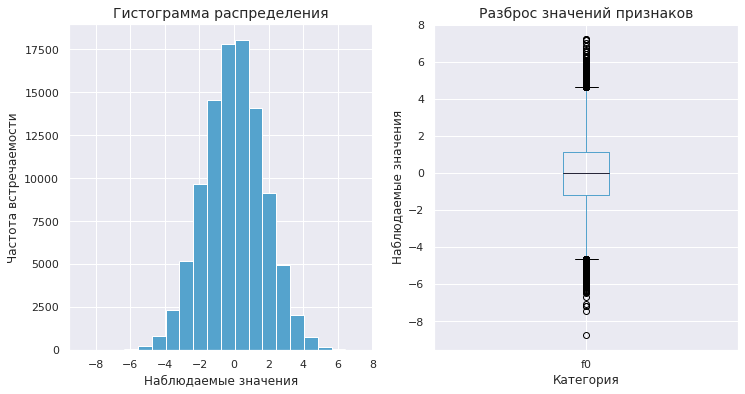

In [41]:
visuals(location_three, 'f0')

<font size="3">
    
**Вывод:**
        
Признак распределён нормально, большинство значений располагается в промежутке от -1.162 до 1.159 со средним значением в 0.002.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "f1"**

count   100,000.000
mean         -0.002
std           1.730
min          -7.084
25%          -1.175
50%          -0.009
75%           1.164
max           7.845
Name: f1, dtype: float64

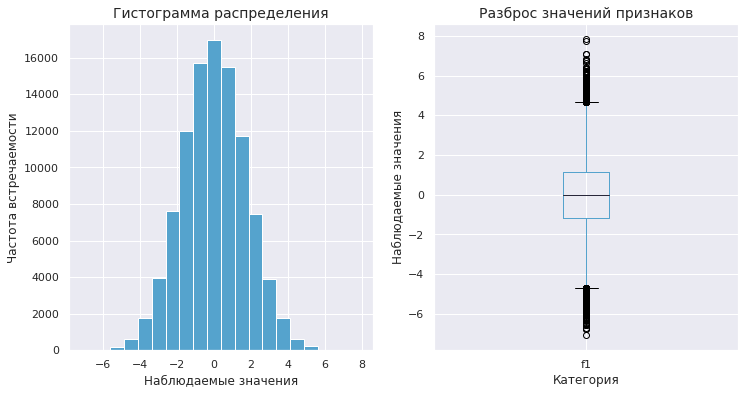

In [42]:
visuals(location_three, 'f1')

<font size="3">
    
**Вывод:**
        
Признак распределён нормально, большинство значений располагается в промежутке от -1.175 до 1.164 со средним значением в -0.002.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "f2"**

count   100,000.000
mean          2.495
std           3.473
min         -11.970
25%           0.130
50%           2.484
75%           4.859
max          16.739
Name: f2, dtype: float64

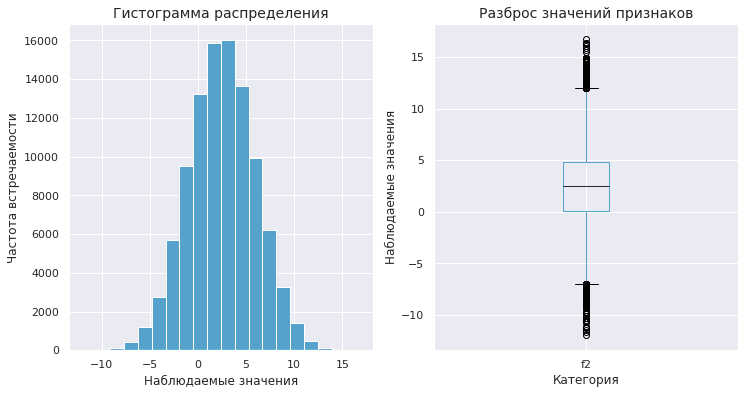

In [43]:
visuals(location_three, 'f2')

<font size="3">
    
**Вывод:**
        
Признак распределён нормально, большинство значений располагается в промежутке от 0.130 до 4.859 со средним значением в 2.495.

Выбросы и аномалии в данных отсутствуют.

<font size="3">
    
- **Признак "product"**

count   100,000.000
mean         95.000
std          44.750
min           0.000
25%          59.450
50%          94.926
75%         130.595
max         190.030
Name: product, dtype: float64

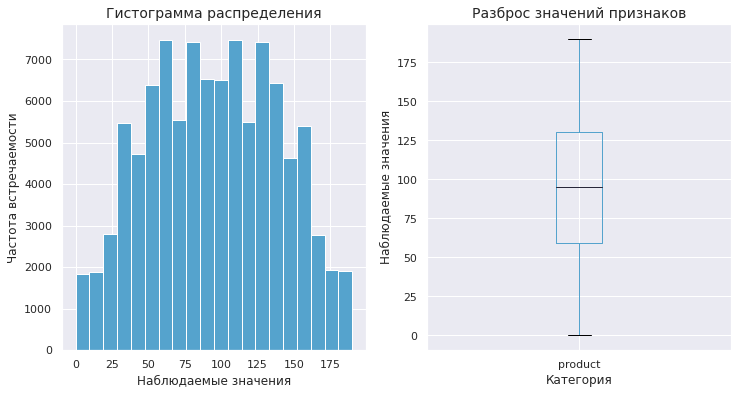

In [44]:
visuals(location_three, 'product')

<font size="3">
    
**Вывод:**
        
Большинство значений признака располагается в промежутке от 59.450 до 130.595 со средним значением в 95.000 тысяч баррелей.

Выбросы и аномалии в данных отсутствуют.

---
<font size="3">

**Вывод**

В датафреймах `location_one`, `location_two` и `location_three` 4 количественных признака. 
    
Выбросов и аномалий в данных не обнаружено.

---
## Корреляционный анализ

<font size="3"> Проведём корреляционный анализ признаков датафреймов. 

Признак `product` - целевой, изучим взаимосвязь входных признаков с целевым, а также выявим мультиколлинеарность признакового описания при его наличии.

<font size="3"> Корреляцию признаков рассмотрим с помощью матрицы корреляций `phik_matrix()`.

In [45]:
def phik_matrix(df):
    # список интервальных признаков
    interval_cols = df.select_dtypes(include='number').columns.tolist()
    
    # вычисление коэффициентов корреляции phi для датафрейма ferma
    phik_overview = df.phik_matrix(interval_cols=interval_cols)

    # визуализация тепловой карты коэффициентов корреляции
    plot_correlation_matrix(
        phik_overview.values,
        x_labels=phik_overview.columns,
        y_labels=phik_overview.index,
        title=r"Матрица корреляции $\phi_K$",
        fontsize_factor=1.5,
        figsize=(10, 7)
    )

<font size="3">
    
**Датафейм `location_one`:**

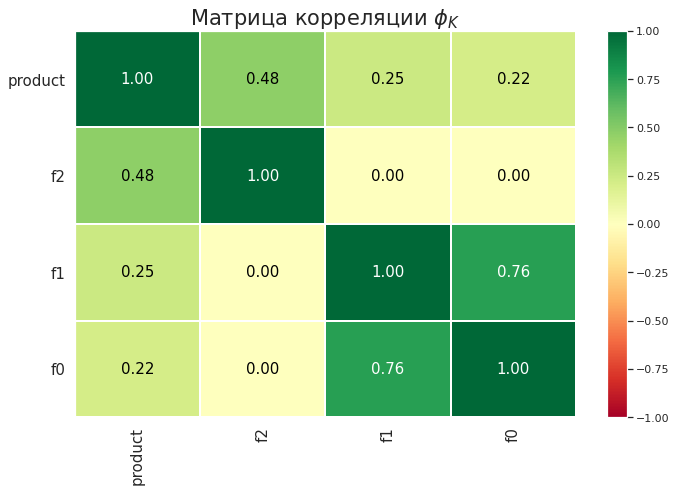

In [46]:
phik_matrix(location_one)

<font size="3">

**Вывод**

Умеренная зависимость с целевым признаком `product` выявлена у признака `f2`.
    
У остальных входных признаков слабая зависимость с целевым.

Мультиколлинеарность входных признаков не выявлена.

---

<font size="3">
    
**Датафейм `location_two`:**

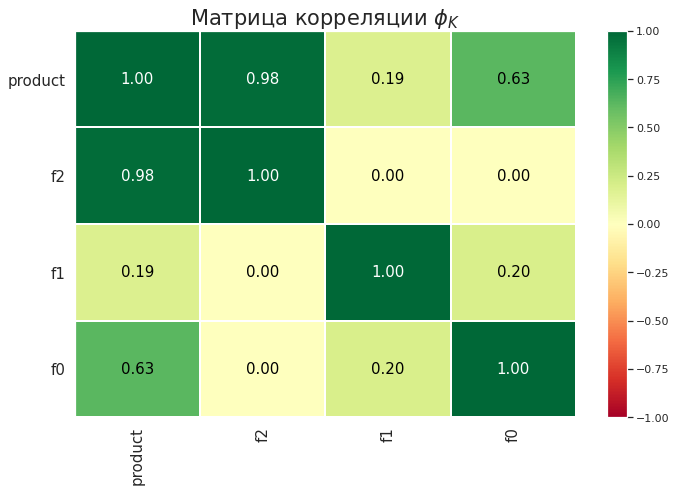

In [47]:
phik_matrix(location_two)

<font size="3">

**Вывод**

Весьма высокая зависимость с целевым признаком `product` выявлена у признака `f2`.

Заметная зависимость - у признака `f0`.
    
Мультиколлинеарность входных признаков не выявлена.

---

<font size="3">
    
**Датафейм `location_three`:**

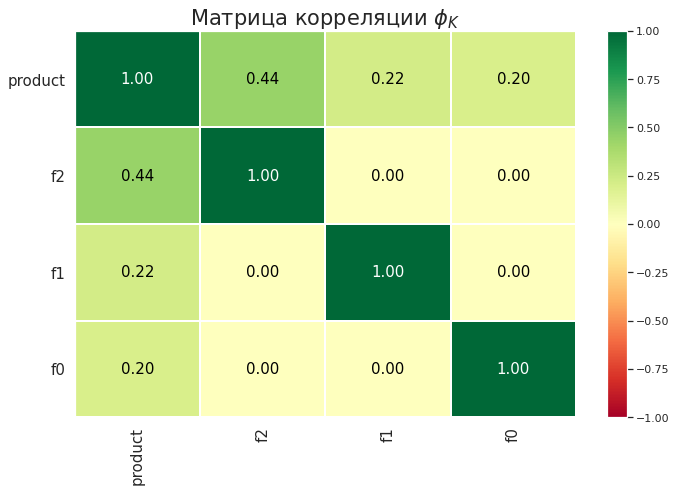

In [48]:
phik_matrix(location_three)

<font size="3">

**Вывод**

Умеренная зависимость с целевым признаком `product` выявлена у признака `f2`.

У остальных входных признаков слабая зависимость с целевым.
    
Мультиколлинеарность входных признаков не выявлена.

### Целевой признак

<font size="3">
    
Целевым в датафреймах является количественный признак `product`, рассмотрим сопряжённость целевого и входных признаков.
    
Напишем функцию для построения графика `scatterplot`, которая визуализирует зависимость целевого признака от входных количественных признаков. 
    
Предварительно в теле функции разобьём наблюдения на 50 корзин и для построения графика возьмём среднее значение каждой корзины. 

In [49]:
def target_numeric(df, quant):
    
    my_bins = pd.cut(df[quant], bins=50)
    data = df[[quant, 'product']].groupby(my_bins).agg(['mean', 'count'])

    fig, axes = plt.subplots(figsize=(12,6))
    
    sns.scatterplot(data=data, x=(quant, 'mean'), y=('product', 'mean'), hue=('product', 'count'),\
                    legend=True, size=('product', 'count'), ax=axes)\
    .set(title='Зависимость признаков "product" и "' + quant + '"')

<font size="3">

**Датафейм `location_one`:**
    
- **Признак "f0"**

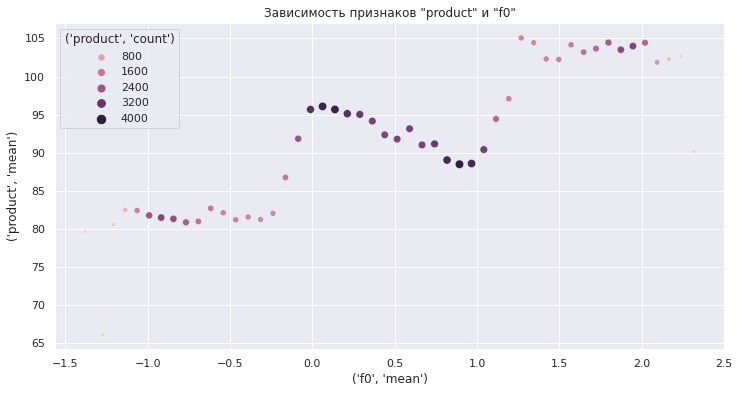

In [50]:
target_numeric (location_one, 'f0')

<font size="3">
    
**Вывод**

Между целевым признаком `product` и входным признаком `f0` отмечается слабая зависимость: высоким значениям `f0` соответствует более высокий объём запасов в скважине.

<font size="3">
    
- **Признак "f1"**

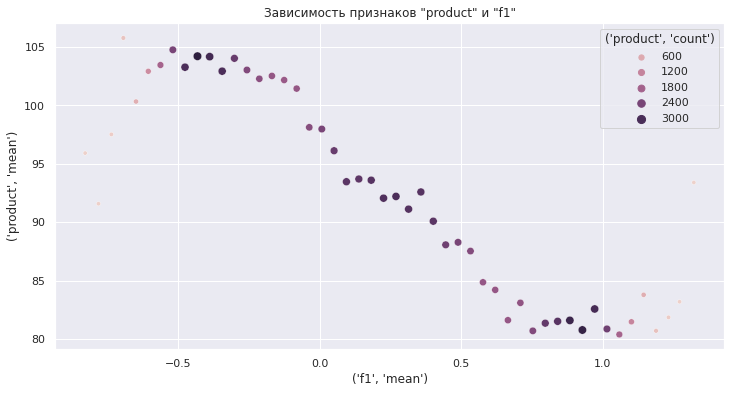

In [51]:
target_numeric (location_one, 'f1')

<font size="3">
    
**Вывод**

Между целевым признаком `product` и входным признаком `f1` отмечается обратная зависимость: высоким значениям `f1` соответствует более низкий объём запасов в скважине.

<font size="3">
    
- **Признак "f2"**

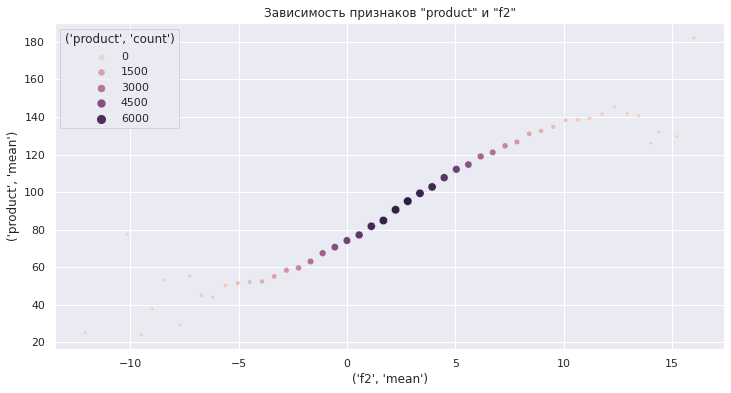

In [52]:
target_numeric (location_one, 'f2')

<font size="3">
    
**Вывод**

Между целевым признаком `product` и входным признаком `f2` отмечается умеренная зависимость: высоким значениям `f2` соответствует более высокий объём запасов в скважине.

<font size="3">

**Датафейм `location_two`:**
    
- **Признак "f0"**

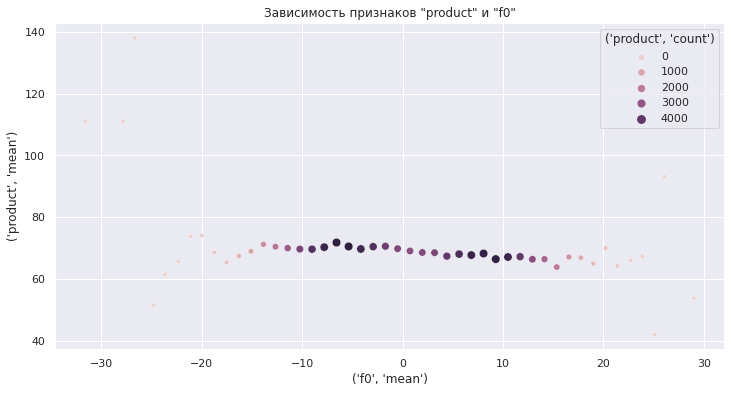

In [53]:
target_numeric (location_two, 'f0')

<font size="3">
    
**Вывод**

Между целевым признаком `product` и входным признаком `f0` отсутствует значимая зависимость.

<font size="3">
    
- **Признак "f1"**

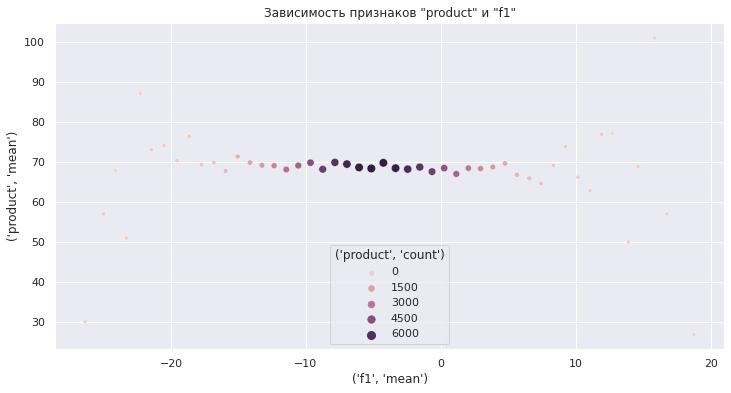

In [54]:
target_numeric (location_two, 'f1')

<font size="3">
    
**Вывод**

Между целевым признаком `product` и входным признаком `f1` отсутствует значимая зависимость.

<font size="3">
    
- **Признак "f2"**

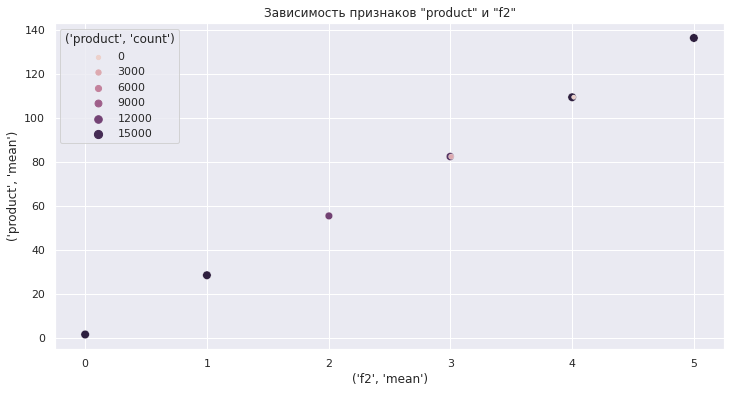

In [55]:
target_numeric (location_two, 'f2')

<font size="3">
    
**Вывод**

Между целевым признаком `product` и входным признаком `f2` отмечается сильная линейная зависимость: высоким значениям `f2` соответствует более высокий объём запасов в скважине.

<font size="3">

**Датафейм `location_three`:**
    
- **Признак "f0"**

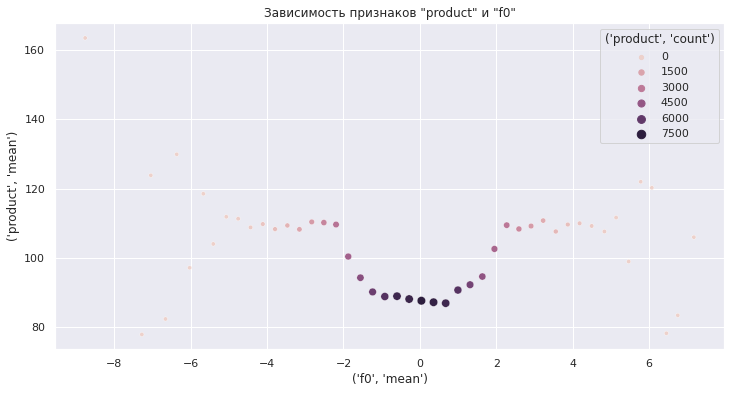

In [56]:
target_numeric (location_three, 'f0')

<font size="3">
    
**Вывод**
    
Можно отметить, что большинство наблюдений расположилось в промежутке значений признака `f0` от -2 до 2, данным наблюдениям соответствует более низкий объём запасов в скважине.

<font size="3">
    
- **Признак "f1"**

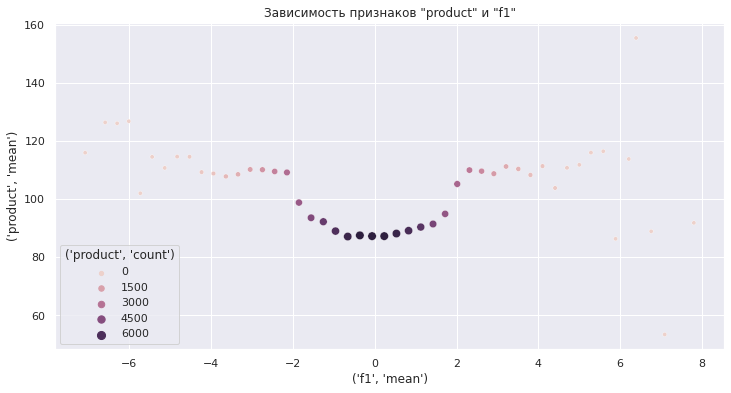

In [57]:
target_numeric (location_three, 'f1')

<font size="3">
    
**Вывод**

Можно отметить, что большинство наблюдений расположилось в промежутке значений признака `f1` от -2 до 2, данным наблюдениям соответствует более низкий объём запасов в скважине.

<font size="3">
    
- **Признак "f2"**

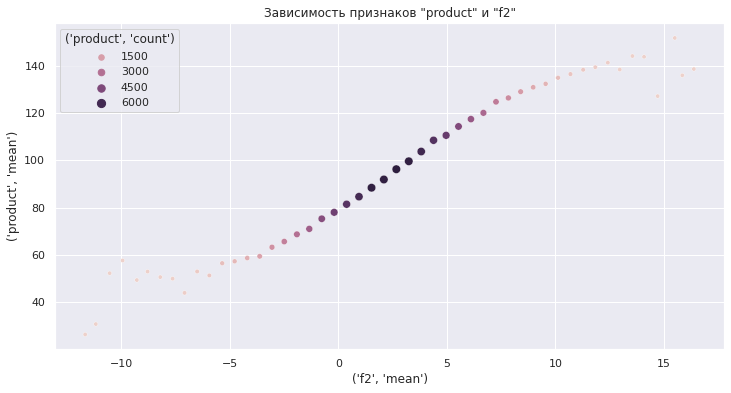

In [58]:
target_numeric (location_three, 'f2')

<font size="3">
    
**Вывод**

Между целевым признаком `product` и входным признаком `f2` отмечается умеренная зависимость: высоким значениям `f2` соответствует более высокий объём запасов в скважине.

---

<font size="3">

**Вывод**
    
Проведён корреляционный анализ и выполнено графическое исследование сопряжённости целевого и входных признаков датафреймов:
    
- `location_one`: 
умеренная зависимость с целевым признаком `product` выявлена у признака `f2`;
    
- `location_two`:
весьма высокая зависимость с целевым признаком `product` выявлена у признака `f2`, заметная зависимость - у признака `f0`;
    
- `location_three`:
умеренная зависимость с целевым признаком `product` выявлена у признака `f2`.

У остальных входных признаков слабая зависимость с целевым.
    

Мультиколлинеарность входных признаков отсутствует.

<div class="alert alert-block alert-success">
<b>Успех:</b> Данные загружены и осмотрены корректно. Радует, что распределения и корреляции были изучены!
</div>

---
## Обучение и проверка модели

<font size="3"> Напишем функцию `model_pipeline` для подготовки данных. 
    
Функция выполнит следующие действия:

- разделит выборку на тренировочные и валидационные данные;
- выполнит масштабирование данных;
- обучит модель на подготовленных данных;
- получит прогноз модели;
- рассчитает метрику `RMSE`;
- рассчитает средний запас сырья в регионе на основе полученного прогноза

In [59]:
def model_pipeline(df):
    # обозначим входные и целевой признаки
    X = df.drop('product', axis=1)
    y = df['product']
    
    # разделим данные на обучающую и валидационную выборки в соотношении 75:25
    X_train, X_valid, y_train, y_valid = train_test_split(
        X, 
        y, 
        test_size=0.25,
        random_state=RANDOM_STATE,
    )
    
    # обнулим индексы строк целевого признака
    y_valid = y_valid.reset_index(drop=True)
    
    # создадим список с количественными признаками
    num_columns = X_train.select_dtypes(include='number').columns.tolist()
    
    # создадим пайплайн для подготовки данных
    data_preprocessor = ColumnTransformer(
        [('num', StandardScaler(), num_columns)], 
        remainder='passthrough'
    )
    
    # создадим итоговый пайплайн: подготовка данных и модель
    pipe_final = Pipeline([
        ('preprocessor', data_preprocessor),
        ('models', LinearRegression())
    ])
    
    # обучим модель на тренировочной выборке
    pipe_final.fit(X_train, y_train)

    # выполним предсказание на валидационных данных
    y_valid_pred = pd.Series(pipe_final.predict(X_valid))
    
    # рассчитаем метрику модели
    print(f'Метрика RMSE на валидационной выборке: {mean_squared_error(y_valid, y_valid_pred, squared=False):.2f}')
    
    # рассчитаем средний запас сырья на основе полученного прогноза
    product_mean = y_valid_pred.mean()
    print(f'Средний запас сырья в регионе: {product_mean:.2f}')
    
    # соединим таргет и прогроз модели в один датафрейм
    y_data = pd.DataFrame({'y_valid': y_valid.to_list(), 'y_pred': (list(y_valid_pred))})
    
    return y_data, product_mean

<font size="3"> Применим написанную функцию к каждому датафрейму, полученный прогноз и таргет каждой выборки сохраним в отдельные переменные.

<font size="3"> 
    
- **`location_one`**
    
Датафрейм с таргетом и прогнозом модели сохраним в переменную `y_data_one`.
Средний запас сырья в регионе запишем в переменную `product_mean_one`.

In [60]:
y_data_one, product_mean_one = model_pipeline(location_one)

Метрика RMSE на валидационной выборке: 37.76
Средний запас сырья в регионе: 92.40


<font size="3"> 
    
- **`location_two`**
    
Датафрейм с таргетом и прогнозом модели сохраним в переменную `y_data_two`. Средний запас сырья в регионе запишем в переменную `product_mean_two`.

In [61]:
y_data_two, product_mean_two = model_pipeline(location_two)

Метрика RMSE на валидационной выборке: 0.89
Средний запас сырья в регионе: 68.71


<font size="3"> 
    
- **`location_three`**
    
Датафрейм с таргетом и прогнозом модели сохраним в переменную `y_data_three`. Средний запас сырья в регионе запишем в переменную `product_mean_three`.

In [62]:
y_data_three, product_mean_three = model_pipeline(location_three)

Метрика RMSE на валидационной выборке: 40.15
Средний запас сырья в регионе: 94.77


<font size="3">

**Вывод**
    
На данном этапе исследования написана модель линейной регрессии с методом оценки качества с помощью метрики `RMSE`.
        
Модель обучена на данных геологоразведки трёх регионов:
- Наименьшее отклонение прогноза от таргета получено на данных второго региона - метрика `RMSE` составила 0.89.
- Наибольший запас сырья в регионе получен в первом (92.40) и третьем (94.77) регионах, во втором регионе прогнозируемый запас сырья составил всего 68.71 тысяч баррелей.

<div class="alert alert-block alert-success">
<b>Успех:</b> Модели обучены корректно. Радует, что ты активно используешь функции. Это помогает избежать дублирования кода, а значит уменьшает вероятность совершить ошибку/опечатку!
</div>

---

## Подготовка к расчёту прибыли

<font size="3"> Сохраним ключевые значения для расчётов в переменные по условиям задачи:
    
* При разведке региона исследуют 500 точек, из которых с помощью машинного обучения выбирают 200 лучших для разработки;
* Бюджет на разработку скважин в регионе — 10 млрд рублей;
* При нынешних ценах один баррель сырья приносит 450 рублей дохода. Доход с каждой единицы продукта составляет 450 тыс. рублей, поскольку объём указан в тысячах баррелей;
* После оценки рисков нужно оставить лишь те регионы, в которых вероятность убытков меньше 2.5%. Среди них выбирают регион с наибольшей средней прибылью.

In [63]:
#количество точек для исследования при разведке региона
EXPLORATION_POINTS = 500

#количество отобранных для разработки точек
SELECTED_POINTS = 200

#бюджет на разработку скважин в регионе
BUDGET = 10000000000

#доход с каждой единицы продукта (в тысячах баррелей)
REVENUE_PER_UNIT = 450000

#порог вероятности убытков
LOSS_THRESHOLD = 0.025

<font size="3"> Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины:
    
- рассчитаем, сколько средств бюджета приходится на разработку одной из выбранных точек;
- рассчитаем необходимое количество сырья, которое позволит нам не выйти за рамки полученного бюджета.

In [64]:
budget_per_point = BUDGET / SELECTED_POINTS
sufficient_product = budget_per_point / REVENUE_PER_UNIT

print(f'Достаточный объём сырья для безубыточной разработки новой скважины: {sufficient_product:.2f}')

Достаточный объём сырья для безубыточной разработки новой скважины: 111.11


<font size="3">
Cравним полученное значение со средним запасом сырья в каждом регионе, для удобства формирования выводов соберём полученные результаты в сравнительную таблицу:

In [65]:
product_results = pd.DataFrame(
    {'Средний_запас_сырья': [product_mean_one, product_mean_two, product_mean_three], 
     'Достаточный_запас_сырья': [sufficient_product]*3
    })

product_results['Разница'] = product_results['Средний_запас_сырья'] - product_results['Достаточный_запас_сырья']

In [66]:
product_results

,Средний_запас_сырья,Достаточный_запас_сырья,Разница
0,92.399,111.111,-18.712
1,68.713,111.111,-42.398
2,94.771,111.111,-16.340


<font size="3">

**Вывод**
    
Для безубыточной разработки новой скважины необходимо 111.11 тысяч баррелей сырья, ни в одном из изученных регионов предсказанный средний запас сырья не превысил данный порог.
    
Можно заключить, что разработка всех скважин в регионе или случайный выбор скважин для разработки не будет безубыточным.

<div class="alert alert-block alert-info">

<b>Совет: </b> В названиях константных переменных лучше использовать только БОЛЬШИЕ буквы. Это соглашение между программистами: https://pythonworld.ru/osnovy/pep-8-rukovodstvo-po-napisaniyu-koda-na-python.html#id29 .
</div>

<div class="alert alert-block alert-success">
<b>Успех:</b> Точка безубыточности найдена верно, сравнение проведено!
</div>

<div class="alert alert-block alert-warning">
<b>Изменения:</b> 
    
Исправилась, переименовала константы, спасибо!
</div>


---

## Расчёт прибыли и рисков 

### Расчёт прибыли

<font size="3"> Напишем функцию для расчёта прибыли по выбранным скважинам и предсказаниям модели:
- Выберем скважины с максимальными значениями предсказаний;
- Просуммируем целевое значение объёма сырья, соответствующее этим предсказаниям;
- Рассчитаем прибыль для полученного объёма сырья.

In [67]:
def profit_region(y_data):
    
    #отбираем скважины с максимальными значениями предсказаний
    best_points = y_data.sort_values(by='y_pred', ascending=False).head(SELECTED_POINTS) 
    
    #суммируем целевое значение объёма сырья для выбранных скважин
    product_sum = best_points['y_valid'].sum()
    
    #считаем прибыль от полученного объёма сырья
    profit_region = product_sum * REVENUE_PER_UNIT - BUDGET
    
    return profit_region, product_sum

<font size="3"> Применим написанную функцию к полученному прогнозу и таргету каждого региона.

<font size="3"> 
    
- **`location_one`**

In [68]:
profit_region_one, product_sum_one = profit_region(y_data_one)

print(f'Прибыль: {profit_region_one:.2f}')
print(f'Суммарный целевой объём сырья: {product_sum_one:.2f}')

Прибыль: 3359141114.46
Суммарный целевой объём сырья: 29686.98


<font size="3"> 
    
- **`location_two`**

In [69]:
profit_region_two, product_sum_two = profit_region(y_data_two)

print(f'Прибыль: {profit_region_two:.2f}')
print(f'Суммарный целевой объём сырья: {product_sum_two:.2f}')

Прибыль: 2415086696.68
Суммарный целевой объём сырья: 27589.08


<font size="3"> 
    
- **`location_three`**

In [70]:
profit_region_three, product_sum_three = profit_region(y_data_three)

print(f'Прибыль: {profit_region_three:.2f}')
print(f'Суммарный целевой объём сырья: {product_sum_three:.2f}')

Прибыль: 2598571759.37
Суммарный целевой объём сырья: 27996.83


<font size="3">

**Вывод**
    
В данном шаге исследования были отобраны 200 скважин с наибольшим прогнозируемым объёмом сырья. Для выбранных скважин рассчитана прибыль от полученного объёма сырья.
    
Максимальная расчётная прибыль получена в первом регионе - 3359 млн рублей.
Наибольший суммарный целевой объём сырья получен также в первом регионе - 29686 тысяч баррелей.

### Расчёт рисков

<font size="3"> Напишем функцию для расчёта рисков и прибыли/убытка для каждого региона: 

- применим технику *Bootstrap* с 1000 выборок, чтобы найти распределение прибыли;
- найдём среднюю прибыль, 95%-й доверительный интервал и риск убытков. 

In [71]:
def bootstrap_samples(y_data):
    
    # укажем количество выборок Bootstrap
    n_samples = 1000
    # укажем размер выборок
    sample_size = EXPLORATION_POINTS
    
    # создадим список для сбора значений прибыли
    values = []
    
    # прогоним цикл n_samples раз
    for i in range(n_samples):
        
        # создадим Bootstrap-выборки размера sample_size с возвращением
        bootstrap_sample = y_data.sample(sample_size, replace=True, random_state=state)
        
        # применим к выборкам написанную функцию расчёта прибыли
        profit = profit_region(bootstrap_sample)[0]
        
        # добавим полученные значения прибыли в список values
        values.append(profit)
    
    # рассчитаем среднее значение прибыли
    values = pd.Series(values)
    profit_mean = values.mean()
    
    # получим нижнюю границу доверительного интервала
    ci_lower = values.quantile(q = 0.025)

    # получим верхнюю границу доверительного интервала
    ci_higher = values.quantile(q = 0.975)
    
    # построим график распределения прибыли с отметкой доверительных интервалов
    fig, axes = plt.subplots(figsize=(12,6))

    values.plot(
        kind = 'hist', 
        bins = 20, 
        title = 'Доверительный интервал распределения значений прибыли по выборкам Bootstrap'
    )
    
    plt.ylabel('Частота встречаемости')
    plt.xlabel('Наблюдаемые значения')
    plt.axvline(ci_lower, color = 'red', ls = '--')
    plt.axvline(ci_higher, color = 'red', ls = '--')
    
    # рассчитаем вероятность получить убыток (отрицательную прибыль)
    loss_probability = (values < 0).mean()
    
    # выведем результаты расчётов на экран
    print(f'Средняя прибыль: {profit_mean:.2f}')
    print(f'95% доверительный интервал: {ci_lower:.2f}, {ci_higher:.2f}')
    print(f'Вероятность убытков: {loss_probability:.3f}, порог вероятности убытков: {LOSS_THRESHOLD:.3f}')
    
    return profit_mean, ci_lower, ci_higher, loss_probability

<font size="3"> Применим написанную функцию к таргету каждого региона, результаты работы функции запишем в отдельные переменные.

<div class="alert alert-block alert-success">
<b>Успех:</b> Отлично, что для подсчета доверительного интервала использовался именно метод квантилей!
</div>

<div class="alert alert-block alert-success">
<b>Успех:</b> Риск найден очень элегантно.
</div>

<font size="3"> 
    
- **`location_one`**

Средняя прибыль: 406278783.42
95% доверительный интервал: -117742136.49, 911737050.75
Вероятность убытков: 0.067, порог вероятности убытков: 0.025


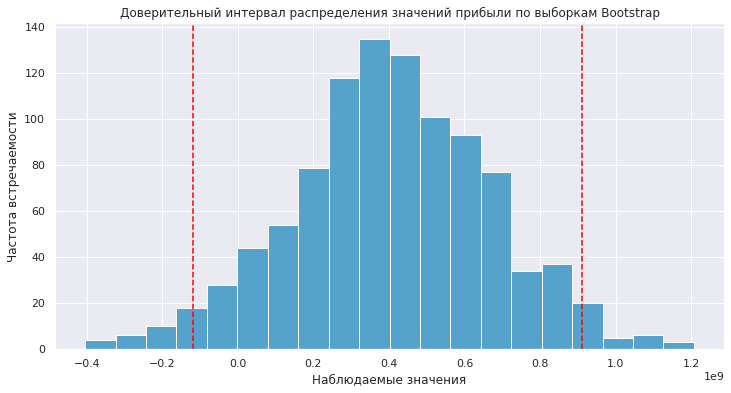

In [72]:
profit_mean_one, ci_lower_one,  ci_higher_one, loss_probability_one = bootstrap_samples(y_data_one)

<font size="3"> 
    
- **`location_two`**

Средняя прибыль: 441504277.59
95% доверительный интервал: 35728489.28, 828006639.00
Вероятность убытков: 0.016, порог вероятности убытков: 0.025


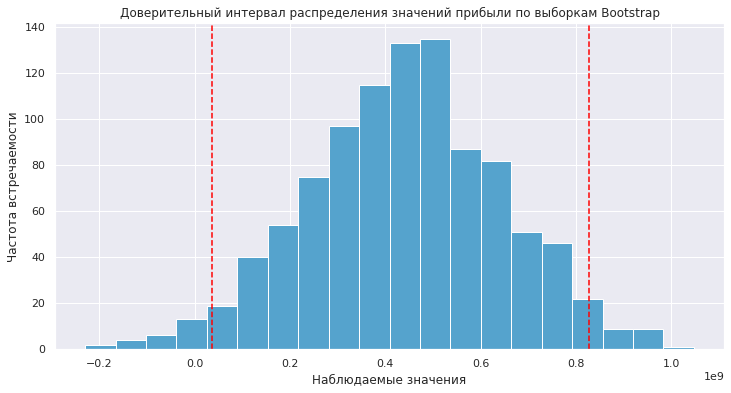

In [73]:
profit_mean_two, ci_lower_two,  ci_higher_two, loss_probability_two = bootstrap_samples(y_data_two)

<font size="3"> 
    
- **`location_three`**

Средняя прибыль: 385213195.91
95% доверительный интервал: -164785166.11, 888206234.20
Вероятность убытков: 0.078, порог вероятности убытков: 0.025


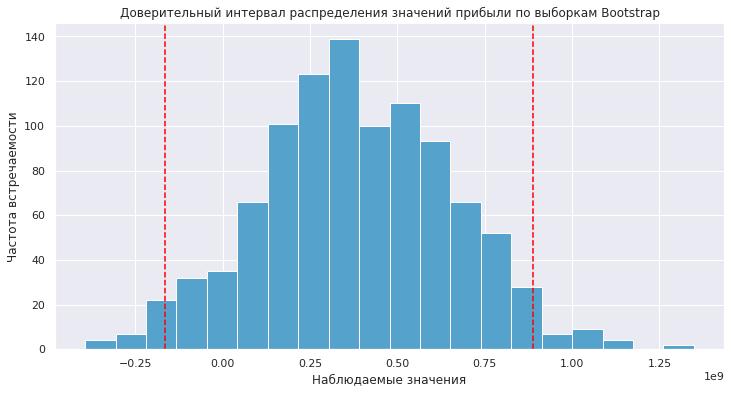

In [74]:
profit_mean_three, ci_lower_three,  ci_higher_three, loss_probability_three = bootstrap_samples(y_data_three)

<font size="3"> Для удобства формирования выводов соберём полученные результаты в сравнительную таблицу: 

In [75]:
results = pd.DataFrame(
    {'profit_mean': [profit_mean_one, profit_mean_two, profit_mean_three], 
     'ci_lower': [ci_lower_one, ci_lower_two, ci_lower_three], 
     'ci_higher': [ci_higher_one, ci_higher_two, ci_higher_three], 
     'loss_probability': [loss_probability_one, loss_probability_two, loss_probability_three], 
     'loss_threshold': [LOSS_THRESHOLD]*3
    })

In [76]:
results

,profit_mean,ci_lower,ci_higher,loss_probability,loss_threshold
0,"406,278,783.424","-117,742,136.495","911,737,050.751",0.067,0.025
1,"441,504,277.592","35,728,489.281","828,006,639.004",0.016,0.025
2,"385,213,195.914","-164,785,166.109","888,206,234.198",0.078,0.025


<font size="3">

**Вывод**
    
- наибольшая средняя прибыль получена во втором регионе; 
- наибольшая нижняя граница доверительного интервала - во втором регионе;
- наименьшая вероятность убытков, не превышающая заданный порог, получена также во втором регионе.

---
## Общий вывод

**Шаг 1. Изучение данных**

Перед проведением исследования данные были изучены:

- импортированы соответствующие библиотеки;
- считаны три датасета с данными геологоразведки: 
  - данные о первом регионе сохранены в переменную `location_one`;
  - данные о втором регионе сохранены в переменную `location_two`;
  - данные о третьем регионе сохранены в переменную `location_three`;
- изучена общая информация о полученных датафреймах;
- изучены имеющиеся пропуски в данных, тип данных, именование столбцов.

**Шаг 2. Предобработка данных**

Проведена предобработка данных:

- Проверены типы данных;
- Изучены пропуски в датафреймах;
- Проверены и обработаны дубликаты в датафреймах, в том числе и неявные.

В ходе проверки дубликатов обнаружено, что значения столбца `id`, уникального идентификатора скважины, не уникальны. Данный столбец удалён во всех датафреймах.

**Шаг 3. Исследовательский анализ данных**

Проведён исследовательский анализ всех признаков датафреймов.

Написана функция `visuals()` для построения гистограммы распределения, коробчатой диаграммы и вывода метода `describe()`.

1. **`location_one`**

- **Признак "f0"**

Признак распределён нормально, большинство значений располагается в промежутке от -0.073 до 1.074 со средним значением в 0.5.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "f1"**

Признак распределён нормально, большинство значений располагается в промежутке от -0.201 до 0.701 со средним значением в 0.25.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "f2"**

Признак распределён нормально, большинство значений располагается в промежутке от 0.288 до 4.715 со средним значением в 2.503.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "product"**

Целевой признак распределён нормально, большинство значений располагается в промежутке от 56.498 до 128.564 со средним значением в 92.500 тысяч баррелей.

Выбросы и аномалии в данных отсутствуют.

2. **`location_two`**

- **Признак "f0"**

Признак распределён нормально, большинство значений располагается в промежутке от -6.299 до 8.621 со средним значением в 1.141.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "f1"**

Признак распределён нормально, большинство значений располагается в промежутке от -8.268 до -1.333 со средним значением в -4.797.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "f2"**

Признак распределён , большинство значений располагается в промежутке от 1.000 до 4.000 со средним значением в 2.495.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "product"**

Признак распределён , большинство значений располагается в промежутке от 26.953 до 107.813 со средним значением в 68.825 тысяч баррелей.

Выбросы и аномалии в данных отсутствуют.

3. **`location_three`**

- **Признак "f0"**

Признак распределён нормально, большинство значений располагается в промежутке от -1.162 до 1.159 со средним значением в 0.002.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "f1"**

Признак распределён нормально, большинство значений располагается в промежутке от -1.175 до 1.164 со средним значением в -0.002.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "f2"**

Признак распределён нормально, большинство значений располагается в промежутке от 0.130 до 4.859 со средним значением в 2.495.

Выбросы и аномалии в данных отсутствуют.

--- 

- **Признак "product"**

Признак распределён нормально, большинство значений располагается в промежутке от 59.450 до 130.595 со средним значением в 95.000 тысяч баррелей.

Выбросы и аномалии в данных отсутствуют.

---

*Вывод*

В датафреймах `location_one`, `location_two` и `location_three` 4 количественных признака. 
    
Выбросов и аномалий в данных не обнаружено.

**Шаг 4. Корреляционный анализ**

Проведён корреляционный анализ признаков датафреймов с помощью матрицы корреляций `phik_matrix()`.

**`location_one`**

Умеренная зависимость с целевым признаком `product` выявлена у признака `f2`.
    
У остальных входных признаков слабая зависимость с целевым.

Мультиколлинеарность входных признаков не выявлена.

**`location_two`**

Весьма высокая зависимость с целевым признаком `product` выявлена у признака `f2`.

Заметная зависимость - у признака `f0`.
    
Мультиколлинеарность входных признаков не выявлена.

**`location_three`**

Умеренная зависимость с целевым признаком `product` выявлена у признака `f2`.

У остальных входных признаков слабая зависимость с целевым.
    
Мультиколлинеарность входных признаков не выявлена.

**Целевой признак**

Признак `product` - целевой, изучена взаимосвязь данного признака с остальными признаками датафрейма.

Написана функция для построения графика scatterplot, которая визуализирует зависимость целевого признака от входных количественных признаков.

Предварительно в теле функции датафрейм сгруппирован по входному количественному признаку и для построения графика выбрано среднее значение каждой группы. 

**`location_one`**

- **Признак "f0"**

Между целевым признаком `product` и входным признаком `f0` отмечается слабая зависимость: высоким значениям `f0` соответствует более высокий объём запасов в скважине.

---

- **Признак "f1"**

Между целевым признаком `product` и входным признаком `f1` отмечается обратная зависимость: высоким значениям `f1` соответствует более низкий объём запасов в скважине.

---

- **Признак "f2"**

Между целевым признаком `product` и входным признаком `f2` отмечается умеренная зависимость: высоким значениям `f2` соответствует более высокий объём запасов в скважине.

**`location_two`**

- **Признак "f0"**

Между целевым признаком `product` и входным признаком `f0` зависимость отсутствует.

---

- **Признак "f1"**

Между целевым признаком `product` и входным признаком `f1` зависимость отсутствует.

---

- **Признак "f2"**

Между целевым признаком `product` и входным признаком `f2` отмечается сильная линейная зависимость: высоким значениям `f2` соответствует более высокий объём запасов в скважине.

**`location_three`**

- **Признак "f0"**

Между целевым признаком `product` и входным признаком `f0` зависимость отсутствует.

---

- **Признак "f1"**

Между целевым признаком `product` и входным признаком `f1` зависимость отсутствует.

---

- **Признак "f2"**

Между целевым признаком `product` и входным признаком `f2` отмечается умеренная зависимость: высоким значениям `f2` соответствует более высокий объём запасов в скважине.

---

*Вывод*

Проведён корреляционный анализ и выполнено графическое исследование сопряжённости целевого и входных признаков датафреймов:
    
- `location_one`: 
Умеренная зависимость с целевым признаком `product` выявлена у признака `f2`.
    
- `location_two`:
Умеренная зависимость с целевым признаком `product` выявлена у признака `f2`.
    
- `location_three`:
Умеренная зависимость с целевым признаком `product` выявлена у признака `f2`.

У остальных входных признаков слабая зависимость с целевым.
    

Мультиколлинеарность входных признаков отсутствует.

**Шаг 5. Обучение и проверка модели**

Написана функция `model_pipeline` для подготовки данных. 
    
Функция выполняет следующие действия:

- делит выборку на тренировочные и валидационные данные;
- выполняет масштабирование данных;
- обучает модель на подготовленных данных;
- получает прогноз модели;
- считает метрику `RMSE`;
- считает средний запас сырья в регионе на основе полученного прогноза

Функция `model_pipeline` применена к каждому датафрейму, полученный прогноз и таргет каждой выборки сохранён в отдельные переменные.

**`location_one`**
- Метрика RMSE на валидационной выборке: 37.76
- Средний запас сырья в регионе: 92.40

**`location_two`**
- Метрика RMSE на валидационной выборке: 0.89
- Средний запас сырья в регионе: 68.71

**`location_three`**
- Метрика RMSE на валидационной выборке: 40.15
- Средний запас сырья в регионе: 94.77

*Вывод*
    
На данном этапе исследования написана модель линейной регрессии с методом оценки качества с помощью метрики `RMSE`.
        
Модель обучена на данных геологоразведки трёх регионов:
- Наименьшее отклонение прогноза от таргета получено на данных второго региона - метрика `RMSE` составила 0.89.
- Наибольший запас сырья в регионе получен в первом (92.40) и третьем (94.77) регионах, во втором регионе прогнозируемый запас сырья составил всего 68.71 тысяч баррелей.

**Шаг 6. Подготовка к расчёту прибыли**

Ключевые значения для расчётов сохранены в константные переменные по условиям задачи.

Рассчитан достаточный объём сырья для безубыточной разработки новой скважины по алгоритму:
    
- рассчитано, сколько средств бюджета приходится на разработку одной из выбранных точек;
- рассчитано необходимое количество сырья, которое позволит нам не выйти за рамки полученного бюджета.

Достаточный объём сырья для безубыточной разработки новой скважины: 111.11

Полученное значение сравнивается со средним запасом сырья в каждом регионе:

- Достаточность среднего запаса сырья в первом регионе: -18.71
- Достаточность среднего запаса сырья в первом регионе: -42.40
- Достаточность среднего запаса сырья в первом регионе: -16.34

*Вывод*
    
Для безубыточной разработки новой скважины необходимо 111.11 тысяч баррелей сырья, ни в одном из изученных регионов предсказанный средний запас сырья не превысил данный порог.
    
Можно заключить, что разработка сразу всех скважин в регионе или случайный выбор скважин для разработки не будет безубыточным.

**Шаг 7. Расчёт прибыли и рисков**

- **Расчёт прибыли**

Написана функция для расчёта прибыли по выбранным скважинам и предсказаниям модели:
- выбраны скважины с максимальными значениями предсказаний;
- суммировано целевое значение объёма сырья, соответствующее этим предсказаниям;
- рассчитана прибыль для полученного объёма сырья.

Функция применена к полученному прогнозу и таргету каждого региона.

**`location_one`**
- Прибыль: 3359141114.46
- Суммарный целевой объём сырья: 29686.98

**`location_two`**
- Прибыль: 2415086696.68
- Суммарный целевой объём сырья: 27589.08

**`location_three`**
- Прибыль: 2598571759.37
- Суммарный целевой объём сырья: 27996.83

*Вывод*
    
В данном шаге исследования были отобраны 200 скважин с наибольшим прогнозируемым объёмом сырья. Для выбранных скважин рассчитана прибыль от полученного объёма сырья.
    
Максимальная расчётная прибыль получена в первом регионе - 3359 млн рублей.
Наибольший суммарный целевой объём сырья получен также в первом регионе - 29686 тысяч баррелей.

- **Расчёт рисков**

Написана функция для расчёта рисков и прибыли/убытка для каждого региона: 

- применена техника *Bootstrap* с 1000 выборок, чтобы найти распределение прибыли;
- найдена средняя прибыль, 95%-й доверительный интервал и риск убытков. 

Функция применена к таргету каждого региона, результаты работы функции записаны в отдельные переменные.

**`location_one`**
- Средняя прибыль: 406 278 783.42
- 95% доверительный интервал: -117 742 136.49, 911 737 050.75
- Вероятность убытков: 0.067, порог вероятности убытков: 0.025

**`location_two`**
- Средняя прибыль: 441 504 277.59
- 95% доверительный интервал: 35 728 489.28, 828 006 639.00
- Вероятность убытков: 0.016, порог вероятности убытков: 0.025

**`location_three`**
- Средняя прибыль: 385 213 195.91
- 95% доверительный интервал: -164 785 166.11, 888 206 234.20
- Вероятность убытков: 0.078, порог вероятности убытков: 0.025

*Вывод*
    
- наибольшая средняя прибыль получена во втором регионе; 
- наибольшая нижняя граница доверительного интервала - во втором регионе;
- наименьшая вероятность убытков, не превышающая заданный порог, получена также во втором регионе.

<font size="3"> **Заключение**

Исследование проводилось с целью определения региона, где добыча нефти принесёт наибольшую прибыль. 
    
В ходе исследования было установлено, что ни в одном из изученных регионов предсказанный средний запас сырья не превысил порог в 111.11 тысяч баррелей, достаточный для безубыточной разработки новой скважины. 
    
Из чего следует, что разработка всех скважин в регионе или случайный выбор скважин для разработки не будет безубыточным.
    
Выбор региона для разработки скважин стоит основывать на рассчитанных показателях рисков и прибыли:
- наибольшее значение средней прибыли получено во втором регионе;
- наибольшая нижняя граница доверительного интервала - во втором регионе;    
- наименьшая вероятность убытков получена также во втором регионе.
    
На основании полученных результатов можно заключить, что для разработки скважин стоит выбрать **второй** регион.

<div class="alert alert-block alert-success">
<b>Успех:</b> С выбором региона согласен.
</div>

---
## Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнен шаг 1: данные подготовлены
- [x]  Выполнен шаг 2: модели обучены и проверены
    - [x]  Данные корректно разбиты на обучающую и валидационную выборки
    - [x]  Модели обучены, предсказания сделаны
    - [x]  Предсказания и правильные ответы на валидационной выборке сохранены
    - [x]  На экране напечатаны результаты
    - [x]  Сделаны выводы
- [x]  Выполнен шаг 3: проведена подготовка к расчёту прибыли
    - [x]  Для всех ключевых значений созданы константы Python
    - [x]  Посчитано минимальное среднее количество продукта в месторождениях региона, достаточное для разработки
    - [x]  По предыдущему пункту сделаны выводы
    - [x]  Написана функция расчёта прибыли
- [x]  Выполнен шаг 4: посчитаны риски и прибыль
    - [x]  Проведена процедура *Bootstrap*
    - [x]  Все параметры бутстрепа соответствуют условию
    - [x]  Найдены все нужные величины
    - [x]  Предложен регион для разработки месторождения
    - [x]  Выбор региона обоснован